In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB

In [2]:
num_cut = 200
num_points = 50

data = []

In [3]:
dx = 0.001
shifts = np.array([0., 
                   0.001, 0.001 + 0.1 * dx, 
                   0.01, 0.01 + dx, 
                   0.05, 0.05 + dx,
                   0.1, 0.1 + dx,
                   0.126, 0.126 + dx,
                   0.158, 0.159 + dx,
                   0.2, 0.2 + dx,
                   0.251, 0.251 + dx,
                   0.316, 0.316 + dx,
                   0.398, 0.398 + dx,
                   0.5, 0.5 + dx,
                   0.631, 0.631 + dx,
                   0.794, 0.794 + dx,
                   1., 1. + dx,
                   2., 2. + dx])
num_shifts = len(shifts)

In [4]:
k = 0
data = []
while (k < 100):
    points = np.zeros((num_cut, num_points, 3), dtype = np.float32)
    for c in range(num_cut):
        for j in range(num_points):
            for i in range(3):
                points[c, j, i] = np.random.uniform(-2. * np.pi, 2. * np.pi)

    points2 = np.zeros((num_cut, num_points, num_shifts, 3), dtype = np.float32)

    for i in range(num_shifts):
        points2[:, :, i, 0] = points[:, :, 0] + shifts[i]
        points2[:, :, i, 1] = points[:, :, 1]
        points2[:, :, i, 2] = points[:, :, 2]

    v = np.zeros((num_cut, num_points, num_shifts, 3))

    # load shared library
    lTDB = pyJHTDB.libJHTDB()
    #initialize webservices
    lTDB.initialize()

    #Add token
    auth_token  = "edu.jhu.pha.turbulence.testing-201311"  #Replace with your own token here
    lTDB.add_token(auth_token)

    for c in range(num_cut):
        v[c] = lTDB.getData(
            0.1,
            points2[c],
            data_set='isotropic1024coarse',
            sinterp = 4,
            getFunction='getVelocity')
        
    for c in range(num_cut):
        for i in range(num_points):
            data.append(v[c, i, :, 0])
    
    np.save(np.array(data))

    np.save('data', np.array(data))

TypeError: save() missing 1 required positional argument: 'arr'

In [12]:
points = np.zeros((num_cut, num_points, 3), dtype = np.float32)
for c in range(num_cut):
    for j in range(num_points):
        for i in range(3):
            points[c, j, i] = np.random.uniform(-2. * np.pi, 2. * np.pi)

points2 = np.zeros((num_cut, num_points, num_shifts, 3), dtype = np.float32)

for i in range(num_shifts):
    points2[:, :, i, 0] = points[:, :, 0] + shifts[i]
    points2[:, :, i, 1] = points[:, :, 1]
    points2[:, :, i, 2] = points[:, :, 2]

v = np.zeros((num_cut, num_points, num_shifts, 3))

In [13]:
# load shared library
lTDB = pyJHTDB.libJHTDB()
#initialize webservices
lTDB.initialize()

#Add token
auth_token  = "edu.jhu.pha.turbulence.testing-201311"  #Replace with your own token here
lTDB.add_token(auth_token)

In [14]:
for c in range(num_cut):
    v[c] = lTDB.getData(
        0.1,
        points2[c],
        data_set='isotropic1024coarse',
        sinterp = 4,
        getFunction='getVelocity')

In [15]:
for c in range(num_cut):
    for i in range(num_points):
        data.append(v[c, i, :, 0])

In [16]:
len(data)

20000

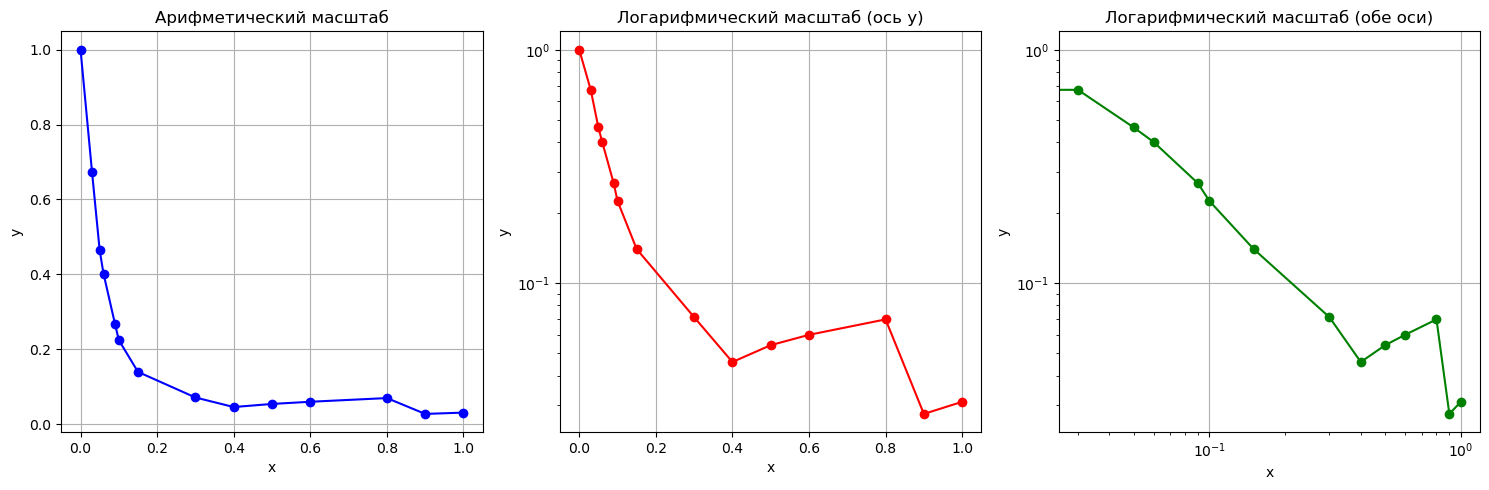

In [2]:
import matplotlib.pyplot as plt

# Данные
x = [0, 0.03, 0.05, 0.05999999, 0.08999999, 0.1, 0.15, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1]
y = [1, 0.672823797, 0.464023793, 0.401853529, 0.267494577, 0.224439264, 0.139589083, 0.071272589, 0.045763272, 0.054033398, 0.059853168, 0.069700167, 0.02740771, 0.030889986]

# Построение в арифметическом масштабе
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.title('Арифметический масштаб')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

# Построение в логарифмическом масштабе по оси y
plt.subplot(1, 3, 2)
plt.semilogy(x, y, marker='o', linestyle='-', color='r')
plt.title('Логарифмический масштаб (ось y)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

# Построение в логарифмическом масштабе по обеим осям (log-log график)
plt.subplot(1, 3, 3)
plt.loglog(x, y, marker='o', linestyle='-', color='g')
plt.title('Логарифмический масштаб (обе оси)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for -: 'int' and 'list'

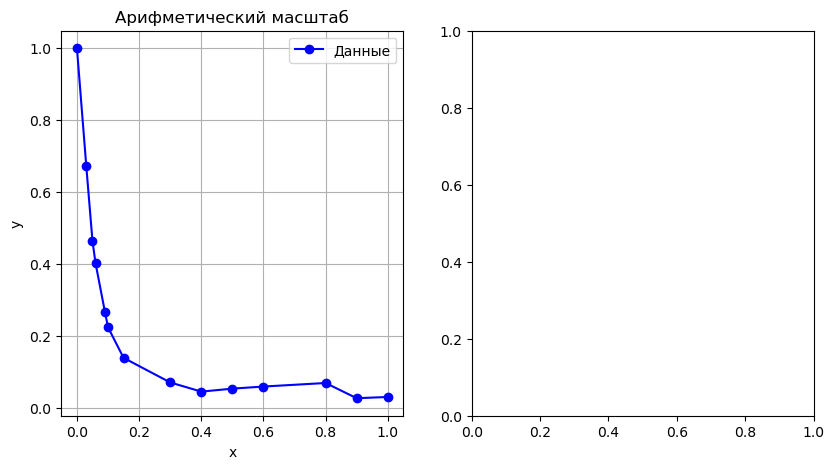

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
x = [0, 0.03, 0.05, 0.05999999, 0.08999999, 0.1, 0.15, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1]
y = [1, 0.672823797, 0.464023793, 0.401853529, 0.267494577, 0.224439264, 0.139589083, 0.071272589, 0.045763272, 0.054033398, 0.059853168, 0.069700167, 0.02740771, 0.030889986]

# Создание массива x для кривой 1 - x^(2/3)
#x_curve = np.linspace(0, 1, 100)
#y_curve = 1 - 2*x_curve**(2/3)

# Построение в арифметическом масштабе
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Данные')
#plt.plot(x_curve, y_curve, linestyle='--', color='r', label='1 - x^(2/3)')
plt.title('Арифметический масштаб')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Построение в логарифмическом масштабе по оси y
plt.subplot(1, 3, 2)
plt.semilogy(x, y, marker='o', linestyle='-', color='b', label='Данные')
#plt.semilogy(x_curve, y_curve, linestyle='--', color='r', label='1 - x^(2/3)')
plt.title('Логарифмический масштаб (ось y)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Построение в логарифмическом масштабе по обеим осям (log-log график)
plt.subplot(1, 3, 3)
plt.loglog(x, y, marker='o', linestyle='-', color='b', label='Данные')
#plt.loglog(x_curve, y_curve, linestyle='--', color='r', label='1 - x^(2/3)')
plt.title('Логарифмический масштаб (обе оси)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

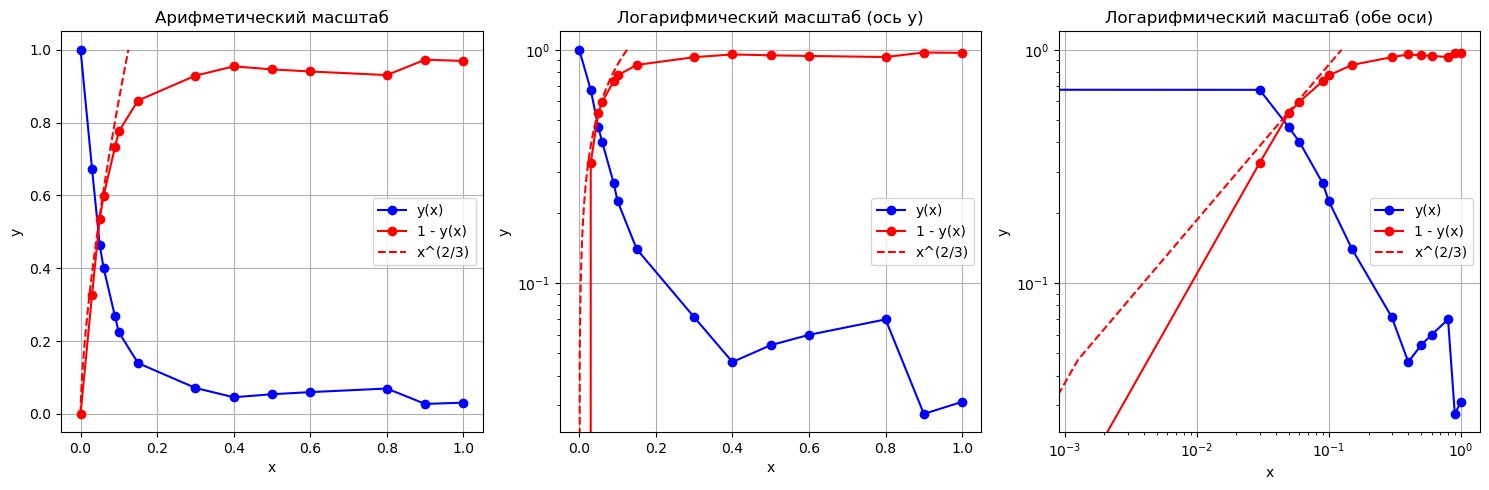

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
x = [0, 0.03, 0.05, 0.05999999, 0.08999999, 0.1, 0.15, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1]
y = [1, 0.672823797, 0.464023793, 0.401853529, 0.267494577, 0.224439264, 0.139589083, 0.071272589, 0.045763272, 0.054033398, 0.059853168, 0.069700167, 0.02740771, 0.030889986]

# Вычисление 1 - y(x)
y_inv = [1 - val for val in y]

# Создание массива x для кривой x^(2/3)
a=4
b= a**(-3/2)
x_curve = np.linspace(0, b, 100)
y_curve = a*x_curve**(2/3)


# Построение в арифметическом масштабе
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, y, marker='o', linestyle='-', color='b', label='y(x)')
plt.plot(x, y_inv, marker='o', linestyle='-', color='r', label='1 - y(x)')
plt.plot(x_curve, y_curve, linestyle='--', color='r', label='x^(2/3)')
plt.title('Арифметический масштаб')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Построение в логарифмическом масштабе по оси y
plt.subplot(1, 3, 2)
plt.semilogy(x, y, marker='o', linestyle='-', color='b', label='y(x)')
plt.semilogy(x, y_inv, marker='o', linestyle='-', color='r', label='1 - y(x)')
plt.plot(x_curve, y_curve, linestyle='--', color='r', label='x^(2/3)')
plt.title('Логарифмический масштаб (ось y)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Построение в логарифмическом масштабе по обеим осям (log-log график)
plt.subplot(1, 3, 3)
plt.loglog(x, y, marker='o', linestyle='-', color='b', label='y(x)')
plt.loglog(x, y_inv, marker='o', linestyle='-', color='r', label='1 - y(x)')
plt.loglog(x_curve, y_curve, linestyle='--', color='r', label='x^(2/3)')
plt.title('Логарифмический масштаб (обе оси)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

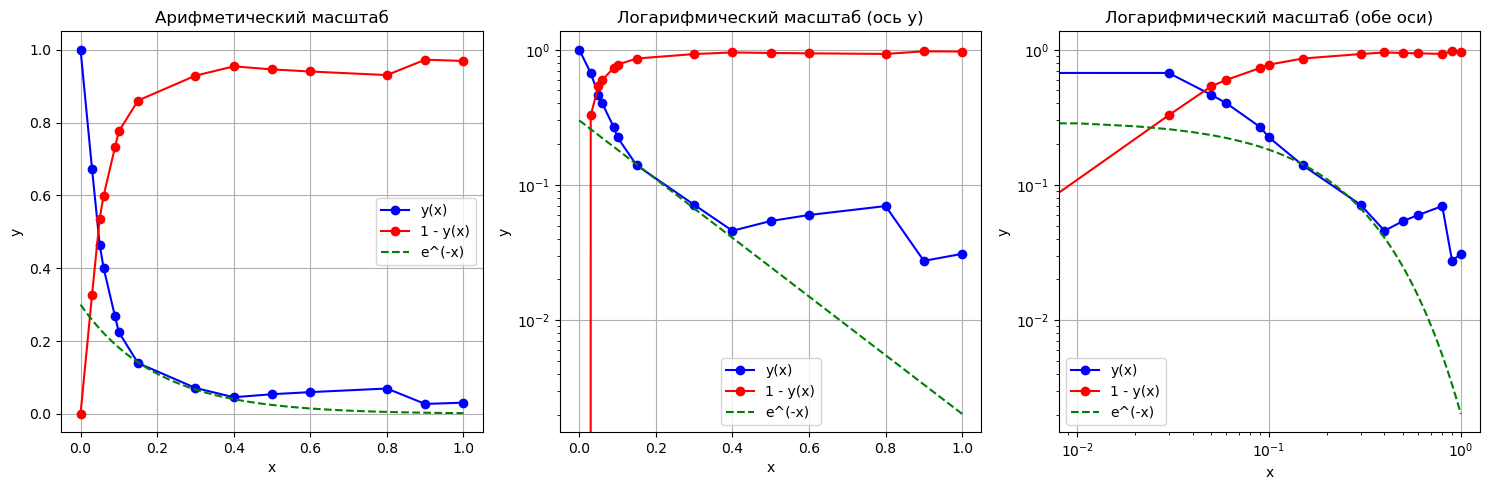

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
x = [0, 0.03, 0.05, 0.05999999, 0.08999999, 0.1, 0.15, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1]
y = [1, 0.672823797, 0.464023793, 0.401853529, 0.267494577, 0.224439264, 0.139589083, 0.071272589, 0.045763272, 0.054033398, 0.059853168, 0.069700167, 0.02740771, 0.030889986]

# Вычисление 1 - y(x)
y_inv = [1 - val for val in y]

# Создание массива x для кривой e^(-x)
x_curve = np.linspace(0, 1, 100)
y_exp = .3* np.exp(-5*(x_curve))

# Построение в арифметическом масштабе
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, y, marker='o', linestyle='-', color='b', label='y(x)')
plt.plot(x, y_inv, marker='o', linestyle='-', color='r', label='1 - y(x)')
plt.plot(x_curve, y_exp, linestyle='--', color='g', label='e^(-x)')
plt.title('Арифметический масштаб')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Построение в логарифмическом масштабе по оси y
plt.subplot(1, 3, 2)
plt.semilogy(x, y, marker='o', linestyle='-', color='b', label='y(x)')
plt.semilogy(x, y_inv, marker='o', linestyle='-', color='r', label='1 - y(x)')
plt.semilogy(x_curve, y_exp, linestyle='--', color='g', label='e^(-x)')
plt.title('Логарифмический масштаб (ось y)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Построение в логарифмическом масштабе по обеим осям (log-log график)
plt.subplot(1, 3, 3)
plt.loglog(x, y, marker='o', linestyle='-', color='b', label='y(x)')
plt.loglog(x, y_inv, marker='o', linestyle='-', color='r', label='1 - y(x)')
plt.loglog(x_curve, y_exp, linestyle='--', color='g', label='e^(-x)')
plt.title('Логарифмический масштаб (обе оси)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
import numpy as np

# Данные
x = [0, 0.03, 0.05, 0.05999999, 0.08999999, 0.1, 0.15, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1]
y = [1, 0.672823797, 0.464023793, 0.401853529, 0.267494577, 0.224439264, 0.139589083, 0.071272589, 0.045763272, 0.054033398, 0.059853168, 0.069700167, 0.02740771, 0.030889986]

# Вычисление площади под кривой методом трапеций
def trapezoidal_rule(x, y):
    n = len(x)
    area = 0
    contributions = []
    for i in range(1, n):
        h = x[i] - x[i-1]
        area_segment = (y[i-1] + y[i]) * h / 2
        area += area_segment
        contributions.append((area_segment, round(x[i-1], 2), round(x[i], 2)))
    return area, contributions

# Вычисление площади и вклада каждого участка
total_area, contributions = trapezoidal_rule(x, y)

# Вывод результатов
print(f"Общая площадь под кривой: {total_area:.8f}")
print("Вклад каждого участка в процентах:")
for i, (contribution, x_start, x_end) in enumerate(contributions):
    percentage = (contribution / total_area) * 100
    print(f"Участок {i+1}: {percentage:.4f}% (Интервал: [{x_start:.2f}, {x_end:.2f}])")

Общая площадь под кривой: 0.11546701
Вклад каждого участка в процентах:
Участок 1: 21.7312% (Интервал: [0.00, 0.03])
Участок 2: 9.8456% (Интервал: [0.03, 0.05])
Участок 3: 3.7495% (Интервал: [0.05, 0.06])
Участок 4: 8.6953% (Интервал: [0.06, 0.09])
Участок 5: 2.1302% (Интервал: [0.09, 0.10])
Участок 6: 7.8817% (Интервал: [0.10, 0.15])
Участок 7: 13.6962% (Интервал: [0.15, 0.30])
Участок 8: 5.0679% (Интервал: [0.30, 0.40])
Участок 9: 4.3214% (Интервал: [0.40, 0.50])
Участок 10: 4.9316% (Интервал: [0.50, 0.60])
Участок 11: 11.2199% (Интервал: [0.60, 0.80])
Участок 12: 4.2050% (Интервал: [0.80, 0.90])
Участок 13: 2.5244% (Интервал: [0.90, 1.00])



t = [0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4] - optimal

In [ ]:
import numpy as np

# Данные

# Распределение точек по степенной функции x^(3/2)
def power_distribution(start, end, num_points, power):
    lin_points = np.linspace(start**power, end**power, num_points)
    return lin_points**(1/power)

# Новые точки по степенной функции x^(3/2)
new_x = power_distribution(0, .15, 7, 3/2)

# Вывод новых точек
print("Новые точки по оси x:")
print(new_x)

Новые точки по оси x:
[0.         0.04542801 0.07211248 0.09449408 0.11447142 0.13283232
 0.15      ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 3  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 3  # 100  # 100  # 800
Nmb_of_Widths = 1  # Обновлено до 1 (две ширины: 0.158 и 0.159)
Nmb_of_TimeSteps = 11  # Количество временных шагов
Width = 0.158  # Обновлено до 0.158
Width2 = 0.159  # Обновлено до 0.159
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03
                        #, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4
                        ])
delta_t = time_shifts

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))
    points21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))

    for I_W in range(Nmb_of_Widths + 1):
        points2[:, I_W, :] = points + I_W * Width * s[:, 0, :]
        points21[:, I_W, :] = points + (I_W + 1) * Width2 * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, Nmb_of_TimeSteps, 3))
    Veloc21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths + 1):
            points3 = points2[:, I_W, :]
            points31 = points21[:, I_W, :]

            Veloc3 = lTDB.getData(
                time_0 + delta_t[I_T],
                points3.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )
            Veloc31 = lTDB.getData(
                time_0 + delta_t[I_T],
                points31.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )

            Veloc2[:, I_W, I_T, :] = Veloc3
            Veloc21[:, I_W, I_T, :] = Veloc31

            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,ilm->ijkm', Veloc2, s)
    v1 = np.einsum('ijkl,ilm->ijkm', Veloc21, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]
    v1_diff = v1 - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, np.newaxis, :]
    v1_diff_0 = v1_diff[:, :, 0, :][:, :, np.newaxis, :]

    Cvv = np.einsum('ijkl,ijml->ijkm', v_diff_0, v_diff)
    Cvv1 = np.einsum('ijkl,ijml->ijkm', v1_diff_0, v1_diff)

    collected_points += Nmb_of_pts_1cycle

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Расчет средних значений скорости по времени для каждого пространственного сдвига
mean_velocities_by_shift = np.mean(Cvv, axis=(0, 2, 3, 4))

# Сохранение данных на диск
np.save(os.path.join(output_dir, 'Veloc2.npy'), Veloc2)
np.save(os.path.join(output_dir, 'Veloc21.npy'), Veloc21)
np.save(os.path.join(output_dir, 'Cvv.npy'), Cvv)
np.save(os.path.join(output_dir, 'Cvv1.npy'), Cvv1)
np.save(os.path.join(output_dir, 'mean_velocities_by_shift.npy'), mean_velocities_by_shift)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1


IndexError: index 4 is out of bounds for axis 0 with size 4

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.158, 0.159])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,ilm->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc2.npy', Veloc2)
save_data(output_dir, 'Cvv.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1


KeyboardInterrupt: 

In [27]:
import numpy as np
import os

# Путь к сохраненному файлу Cvv.npy
output_dir = 'velocity_data'
file_path = os.path.join(output_dir, 'Cvv_2.npy')

# Загрузка данных из файла
Cvv = np.load(file_path)

# Вывод формы массива Cvv
print("Shape of Cvv:", Cvv.shape)

# Описание массива Cvv
print("""
Описание массива Cvv:
- Первый индекс (width_index): Определяет ширину (от 0 до Nmb_of_Widths).
- Второй индекс (time_step_index): Определяет временной шаг (от 0 до Nmb_of_TimeSteps - 1).
- Третий и четвертый индексы (i и j): Определяют компоненты вектора скорости (от 0 до 2).
  Каждый элемент массива представляет собой матрицу 3x3, которая описывает корреляцию между компонентами вектора скорости.
""")

#Пример вывода данных для конкретной ширины и временного шага
width_index = 2
time_step_index = 6
print(f"Cvv data for width index {width_index} and time step index {time_step_index}:")
print(Cvv[width_index, time_step_index])

Shape of Cvv: (3, 12, 3, 3)

Описание массива Cvv:
- Первый индекс (width_index): Определяет ширину (от 0 до Nmb_of_Widths).
- Второй индекс (time_step_index): Определяет временной шаг (от 0 до Nmb_of_TimeSteps - 1).
- Третий и четвертый индексы (i и j): Определяют компоненты вектора скорости (от 0 до 2).
  Каждый элемент массива представляет собой матрицу 3x3, которая описывает корреляцию между компонентами вектора скорости.

Cvv data for width index 2 and time step index 6:
[[ 0.10703491 -0.00381558  0.00172063]
 [-0.00367887  0.09964657  0.00252203]
 [ 0.01178159 -0.00062121  0.11149707]]


In [9]:
Nmb_of_TimeSteps

4

In [12]:
v_diff.shape

(3, 3, 4, 3)

In [13]:

v_diff_0.shape

(3, 3, 1, 3)

In [ ]:
Nmb_of_TimeSteps

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [6]:
import numpy as np
import os

# Путь к сохраненному файлу Cvv.npy
output_dir = 'velocity_data'
file_path = os.path.join(output_dir, 'Cvv251_2.npy')

# Загрузка данных из файла
Cvv = np.load(file_path)

# Вывод формы массива Cvv
print("Shape of Cvv:", Cvv.shape)

# Описание массива Cvv
print("""
Описание массива Cvv:
- Первый индекс (width_index): Определяет ширину (от 0 до Nmb_of_Widths).
- Второй индекс (time_step_index): Определяет временной шаг (от 0 до Nmb_of_TimeSteps - 1).
- Третий и четвертый индексы (i и j): Определяют компоненты вектора скорости (от 0 до 2).
  Каждый элемент массива представляет собой матрицу 3x3, которая описывает корреляцию между компонентами вектора скорости.
""")

#Пример вывода данных для конкретной ширины и временного шага
width_index = 1
time_step_index = 4
print(f"Cvv data for width index {width_index} and time step index {time_step_index}:")
print(Cvv[width_index, time_step_index])

Shape of Cvv: (3, 12, 3, 3)

Описание массива Cvv:
- Первый индекс (width_index): Определяет ширину (от 0 до Nmb_of_Widths).
- Второй индекс (time_step_index): Определяет временной шаг (от 0 до Nmb_of_TimeSteps - 1).
- Третий и четвертый индексы (i и j): Определяют компоненты вектора скорости (от 0 до 2).
  Каждый элемент массива представляет собой матрицу 3x3, которая описывает корреляцию между компонентами вектора скорости.

Cvv data for width index 1 and time step index 4:
[[ 0.12943083  0.00530115  0.00415538]
 [ 0.00287768  0.22989413  0.00479626]
 [ 0.00659433 -0.00801815  0.18950015]]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2


: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

# Завершение работы с JHTDB
lTDB.finalize()

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
J=0, I_T=8, I_W=0
J=0, I_T=8, I_W=1
J=0, I_T=8, I_W=2
J=0, I_T=9, I_W=0
J=0, I_T=9, I_W=1
J=0, I_T=9, I_W=2
J=0, I_T=10, I_W=0
J=0, I_T=10, I_W=1
J=0, I_T=10, I_W=2
J=0, I_T=11, I_W=0
J=0, I_T=11, I_W=1
J=0, I_T=11, I_W=2
J=1, I_T=0, I_W=0
J=1, I_T=0, I_W=1
J=1, I_T=0, I_W=2
J=1, I_T=1, I_W=0
J=1, I_T=1, I_W=1
J=1, I_T=1, I_W=2
J=1, I_T=2, I_W=0
J=1, I_T=2, I_W=1
J=1, I_T=2, I_W=2
J=1, I_T=3, I_W=0
J=1, I_T=3, I_W=1
J=1, I_T=3, I_W=2
J=1, I_T=4, I_W=0
J=1, I_T=4, I_W=1
J=1, I_T=4, I_W=2
J=1, I_T=5, I_W=0
J=1, I_T=5, I_W=1
J=1, I_T=5, I_W=2
J=1, I_T=6, I_W=0
J=1,

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

J=0, I_T=0, I_W=0
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
J=0, I_T=1, I_W=0
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
J=0, I_T=2, I_W=0
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
J=0, I_T=3, I_W=0
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
J=0, I_T=4, I_W=0
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
J=0, I_T=5, I_W=0
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
J=0, I_T=6, I_W=0
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
J=0, I_T=7, I_W=0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 2000  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 10  # 100  # 100  # 800
time_0 = 0.2  # Начальное время

# Новые временные сдвиги
time_shifts = np.array([0, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.13, 0.17, 0.22, 0.3, 0.4])
Nmb_of_TimeSteps = len(time_shifts)

# Новые ширины
widths = np.array([0, 0.251, 0.252])
Nmb_of_Widths = len(widths)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, 3))

    for I_W in range(Nmb_of_Widths):
        if widths[I_W] == 0:
            points2[:, I_W, :] = points
        else:
            points2[:, I_W, :] = points + widths[I_W] * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths, Nmb_of_TimeSteps, 3))

    for I_T in range(Nmb_of_TimeSteps):
        for I_W in range(Nmb_of_Widths):
            points3 = points2[:, I_W, :]

            try:
                Veloc3 = lTDB.getData(
                    time_0 + time_shifts[I_T],
                    points3.astype(np.float32),
                    data_set='isotropic1024',
                    sinterp=4,
                    getFunction='getVelocity'
                )
            except Exception as e:
                print(f"Error fetching data: {e}")
                continue

            Veloc2[:, I_W, I_T, :] = Veloc3
            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,iml->ijkm', Veloc2, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]

    # Исправление: добавление недостающего измерения
    v_diff_0 = v_diff[:, :, 0, :][:, :, None, :]

    # Вычисление корреляторов без свертки
    Cvv = np.einsum('ijkl,ijnp->ijnlp', v_diff_0, v_diff)

    # Усреднение по Nmb_of_pts_1cycle
    Cvv = np.mean(Cvv, axis=0)

    collected_points += Nmb_of_pts_1cycle


end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных на диск с проверкой на существование файлов и созданием уникальных имен
def save_data(output_dir, filename, data):
    full_path = os.path.join(output_dir, filename)
    if os.path.exists(full_path):
        base_name, ext = os.path.splitext(filename)
        counter = 1
        while os.path.exists(full_path):
            new_filename = f"{base_name}_{counter}{ext}"
            full_path = os.path.join(output_dir, new_filename)
            counter += 1
        print(f"File {filename} already exists. Saving as {new_filename}.")
    np.save(full_path, data)

save_data(output_dir, 'Veloc251.npy', Veloc2)
save_data(output_dir, 'Cvv251.npy', Cvv)

print(f"Data saved to {output_dir}")